In [1]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta
import joblib
import random
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'c:\\Users\\DELL\\Documents\\PRAXIS\\Projects\\Capstone_Project_final\\backend\\utils'

In [3]:
# ============================================================
# 1️⃣ Paths & Constants
# ============================================================

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "..", "data", "stock_data")
OUTPUT_DIR = os.path.join(BASE_DIR, "..", "data", "processed_data")

os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_WINDOW = 10
PRED_WINDOW = 5
TEST_MONTHS = 6  # Last 6 months for testing

print(f"📂 Stock data directory: {DATA_DIR}")
print(os.path.abspath(DATA_DIR))
print(f"📁 Processed output directory: {OUTPUT_DIR}")
print(os.path.abspath(OUTPUT_DIR))

📂 Stock data directory: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\stock_data
c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\data\stock_data
📁 Processed output directory: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data
c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\data\processed_data


In [4]:
# ============================================================
# 2️⃣ Helper Functions
# ============================================================

def load_stock_csv(file_path):
    """Load and clean a stock CSV (Date, Close)."""
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]
    
    # Handle cases where first line may be ticker name
    if not np.issubdtype(df["Date"].dtype, np.datetime64):
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    df = df.dropna(subset=["Date", "Close"])
    df = df.sort_values("Date").reset_index(drop=True)
    return df

def make_windows(data, input_window=10, pred_window=5):
    """Generate rolling window datasets (X, y)."""
    X, y = [], []
    for i in range(len(data) - input_window - pred_window + 1):
        X.append(data[i : i + input_window])
        y.append(data[i + input_window : i + input_window + pred_window])
    return np.array(X), np.array(y)

In [5]:
# ============================================================
# 3️⃣ Processing Each Sector & Stock
# ============================================================

today = datetime.today()
test_start_date = today - timedelta(days=TEST_MONTHS * 30)

print(f"\n🕒 Today's date: {today.strftime('%Y-%m-%d')}")
print(f"🧪 Test window starts from: {test_start_date.strftime('%Y-%m-%d')}")

for sector_path in glob.glob(os.path.join(DATA_DIR, "*")):
    if not os.path.isdir(sector_path):
        continue
    
    sector_name = os.path.basename(sector_path)
    print(f"\n📊 Processing sector: {sector_name}")
    
    sector_output = os.path.join(OUTPUT_DIR, sector_name)
    os.makedirs(sector_output, exist_ok=True)
    
    for csv_file in glob.glob(os.path.join(sector_path, "*.csv")):
        ticker = os.path.splitext(os.path.basename(csv_file))[0]
        print(f"   ⚙️ {ticker} ...", end=" ")
        
        try:
            df = load_stock_csv(csv_file)
            if df.empty:
                print("⚠️ No data.")
                continue

            # ============================================================
            # 4️⃣ Split into train/test based on 6-month dynamic window
            # ============================================================
            train_df = df[df["Date"] < test_start_date].copy()
            test_df = df[df["Date"] >= test_start_date].copy()

            if len(train_df) < 50 or len(test_df) < 20:
                print("⚠️ Insufficient data.")
                continue

            # ============================================================
            # 5️⃣ Scale Close prices
            # ============================================================
            scaler = MinMaxScaler()
            scaled_train = scaler.fit_transform(train_df[["Close"]])
            scaled_test = scaler.transform(test_df[["Close"]])

            # Save scaler for later inverse transform
            scaler_path = os.path.join(sector_output, f"{ticker}_scaler.pkl")
            joblib.dump(scaler, scaler_path)

            # ============================================================
            # 6️⃣ Create rolling windows (train/test)
            # ============================================================
            X_train, y_train = make_windows(scaled_train, INPUT_WINDOW, PRED_WINDOW)
            X_test, y_test = make_windows(scaled_test, INPUT_WINDOW, PRED_WINDOW)

            # ============================================================
            # 7️⃣ Final forecast window (last 10 days from full data)
            # ============================================================
            all_scaled = scaler.transform(df[["Close"]])
            X_forecast = np.array([all_scaled[-INPUT_WINDOW:].flatten()])

            # ============================================================
            # 8️⃣ Save as compressed .npz files
            # ============================================================
            npz_path = os.path.join(sector_output, f"{ticker}.npz")
            np.savez_compressed(
                npz_path,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                X_forecast=X_forecast
            )

            print(f"✅ Saved: {npz_path} ({X_train.shape[0]} train windows, {X_test.shape[0]} test windows)")

        except Exception as e:
            print(f"❌ Error: {e}")

print("\n🎯 All sectors processed and saved in 'backend/data/processed_data/'")


🕒 Today's date: 2025-11-07
🧪 Test window starts from: 2025-05-11

📊 Processing sector: Auto
   ⚙️ BAJAJ-AUTO ... ✅ Saved: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data\Auto\BAJAJ-AUTO.npz (564 train windows, 111 test windows)
   ⚙️ EICHERMOT ... ✅ Saved: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data\Auto\EICHERMOT.npz (564 train windows, 110 test windows)
   ⚙️ M&M ... ✅ Saved: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data\Auto\M&M.npz (564 train windows, 111 test windows)
   ⚙️ MARUTI ... ✅ Saved: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data\Auto\MARUTI.npz (564 train windows, 110 test windows)
   ⚙️ TATAMOTORS ... ✅ Saved: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\utils\..\data\processed_data\Auto\TATAMOTORS.npz (564 train windows, 111 test 

In [6]:
# ============================================================
# ✅ Verification: Inspect processed .npz and scaler
# ============================================================

# Pick a random sector and stock file
sector_dirs = [d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))]
sector_choice = random.choice(sector_dirs)
sector_path = os.path.join(OUTPUT_DIR, sector_choice)

stock_files = [f for f in os.listdir(sector_path) if f.endswith(".npz")]
stock_choice = random.choice(stock_files)

npz_path = os.path.join(sector_path, stock_choice)
scaler_path = npz_path.replace(".npz", "_scaler.pkl")

print(f"\n🔍 Checking: {sector_choice}/{stock_choice}")

# Load .npz data
data = np.load(npz_path)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
X_forecast = data["X_forecast"]

print(f"🧾 X_train shape: {X_train.shape}")
print(f"🧾 y_train shape: {y_train.shape}")
print(f"🧾 X_test shape: {X_test.shape}")
print(f"🧾 y_test shape: {y_test.shape}")
print(f"🧾 X_forecast shape: {X_forecast.shape}")

# Load and inspect scaler
scaler = joblib.load(scaler_path)
print("\n🔢 Example inverse transform (first forecast window):")
print(scaler.inverse_transform(X_forecast.reshape(-1, 1)).flatten()[:10])



🔍 Checking: Healthcare/MAXHEALTH.npz
🧾 X_train shape: (564, 10, 1)
🧾 y_train shape: (564, 5, 1)
🧾 X_test shape: (110, 10, 1)
🧾 y_test shape: (110, 5, 1)
🧾 X_forecast shape: (1, 10)

🔢 Example inverse transform (first forecast window):
[1211.         1184.09997559 1186.40002441 1179.69995117 1189.5
 1178.5        1147.80004883 1145.90002441 1138.40002441 1125.40002441]


🔎 Loading CSV from: c:\Users\DELL\Documents\PRAXIS\Projects\Capstone_Project_final\backend\data\stock_data\Healthcare\MAXHEALTH.csv


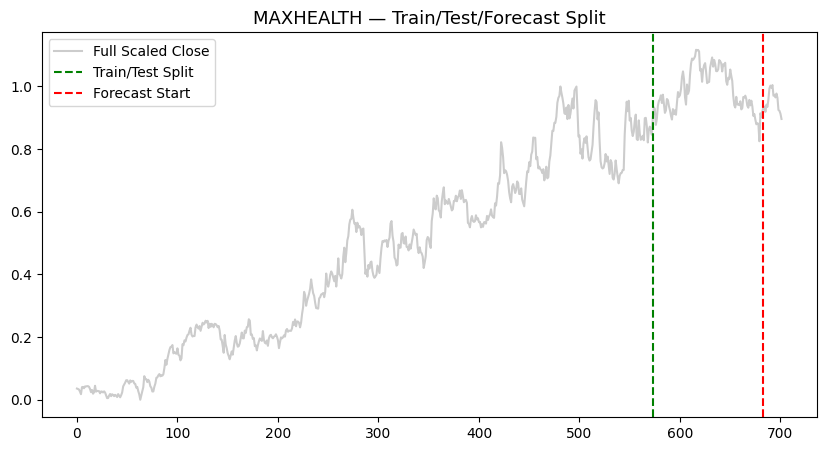

In [7]:
# ============================================================
# 📊 Visual Check: Train vs Test vs Forecast Split
# ============================================================

# ============================================================
# 📊 Visual Check: Train vs Test vs Forecast Split
# ============================================================

# Load full original stock data (to plot reference)
csv_file = os.path.join(BASE_DIR, "..", "data", "stock_data", sector_choice, stock_choice.replace(".npz", ".csv"))
csv_file = os.path.abspath(csv_file)  # ensure absolute path
print(f"🔎 Loading CSV from: {csv_file}")

if not os.path.exists(csv_file):
    raise FileNotFoundError(f"❌ CSV file not found at: {csv_file}")

# Load full original stock data (to plot reference)
# csv_file = os.path.join(BASE_DIR, "data", "stock_data", sector_choice, stock_choice.replace(".npz", ".csv"))
raw_df = pd.read_csv(csv_file)

# Scale again for comparison
scaled_close = scaler.transform(raw_df[["Close"]])

train_len = len(X_train) + 10 - 1  # approximate offset for plotting
test_len = len(X_test)

plt.figure(figsize=(10, 5))
plt.title(f"{stock_choice.replace('.npz','')} — Train/Test/Forecast Split", fontsize=13)
plt.plot(scaled_close, label="Full Scaled Close", color="gray", alpha=0.4)
plt.axvline(train_len, color="green", linestyle="--", label="Train/Test Split")
plt.axvline(train_len + test_len, color="red", linestyle="--", label="Forecast Start")
plt.legend()
plt.show()